# 🚗 Second-Hand Car Price Prediction using Linear Regression

## Project Overview

This notebook builds a **multiple linear regression model** to predict the **selling price of used cars**
based on key vehicle attributes such as mileage, engine volume, brand, body type, and fuel type.

### 🎯 Objective
Given a dataset of used-car listings, the goal is to train a model that can accurately estimate
a car's market price. This is practically useful for:
- **Buyers** — determine whether a listed price is fair
- **Sellers** — price a vehicle competitively
- **Dealers** — automate price assessments at scale

### 📦 Dataset
The dataset contains real-world used-car listings with the following features:

| Feature | Description |
|---|---|
| `Brand` | Car manufacturer (e.g., Audi, BMW, Toyota) |
| `Body` | Body style (e.g., sedan, hatch, crossover) |
| `Mileage` | Total kilometres driven |
| `EngineV` | Engine displacement in litres |
| `Engine Type` | Fuel type (Diesel, Petrol, Gas, Other) |
| `Registration` | Whether the car has valid registration |
| `Year` | Year of manufacture |
| `Price` | Selling price in USD *(target variable)* |

### 🔧 Methodology
The project follows the standard ML pipeline:
1. **Data Cleaning** — handle missing values and remove outliers
2. **Exploratory Analysis** — understand distributions and feature relationships
3. **OLS Assumption Checks** — linearity, normality, multicollinearity
4. **Feature Engineering** — log-transform the target, encode categoricals
5. **Model Training** — fit a LinearRegression on an 80/20 train/test split
6. **Evaluation** — assess R², residuals, and prediction accuracy on unseen data


## 1. Import Libraries

We import the core libraries needed for data manipulation, visualisation, statistical testing, and model building.

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Dataset

We load the raw CSV file and inspect the first few rows to understand the structure of the data.

In [2]:
raw_data = pd.read_csv("1.04.+Real-life+example.csv")
print(f"Dataset shape: {raw_data.shape[0]} rows x {raw_data.shape[1]} columns")
raw_data.head()

Dataset shape: 4345 rows x 9 columns


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


## 3. Data Preprocessing

### 3.1 Descriptive Statistics

Before any cleaning, we examine summary statistics for all variables. This gives us:
- The **range and spread** of numerical features
- The **number of unique values** for categorical features
- Early signals of **outliers or data quality issues**


In [3]:
raw_data.describe(include="all")

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


### 3.2 Drop the `Model` Column

The `Model` column contains hundreds of unique car model names (e.g., "Golf", "Corolla", "3 Series").
Including it would create too many dummy variables and introduce noise without adding meaningful
predictive signal — the `Brand` column already captures manufacturer-level effects.
We drop it to keep the feature space manageable.


In [4]:
data = raw_data.drop("Model", axis=1)
data.describe(include="all")

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


### 3.3 Handle Missing Values

We check how many missing values exist per column.
Linear regression cannot handle NaN values — every row fed to the model must be complete.

> **Rule of thumb:** If missing rows are less than 5% of the total dataset, dropping them
> outright is generally safe and introduces minimal bias.


In [5]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})

,Missing Count,Missing %
Brand,0,0.00
Price,172,3.96
Body,0,0.00
Mileage,0,0.00
EngineV,150,3.45
Engine Type,0,0.00
Registration,0,0.00
Year,0,0.00


In [6]:
# Both Price (172 missing) and EngineV (150 missing) are under 5% of total rows — safe to drop
data_no_mv = data.dropna(axis=0)
print(f"Rows before dropping NaNs : {len(data)}")
print(f"Rows after  dropping NaNs : {len(data_no_mv)}")
data_no_mv.isnull().sum()

Rows before dropping NaNs : 4345
Rows after  dropping NaNs : 4025


Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
dtype: int64

### 3.4 Explore Distributions and Handle Outliers

We plot the **Probability Density Function (PDF)** of each continuous variable to:
- Check for **skewness** (asymmetric distributions)
- Identify **extreme outliers** that would distort the regression line

A right-skewed price distribution is typical in used-car markets — most vehicles are budget-priced,
with a long tail of premium and luxury cars.

**Strategy:** Remove the top/bottom 1% of each numerical variable where extreme values are evident.
We also apply domain knowledge: a standard road car cannot physically have an engine larger than 6.5L.


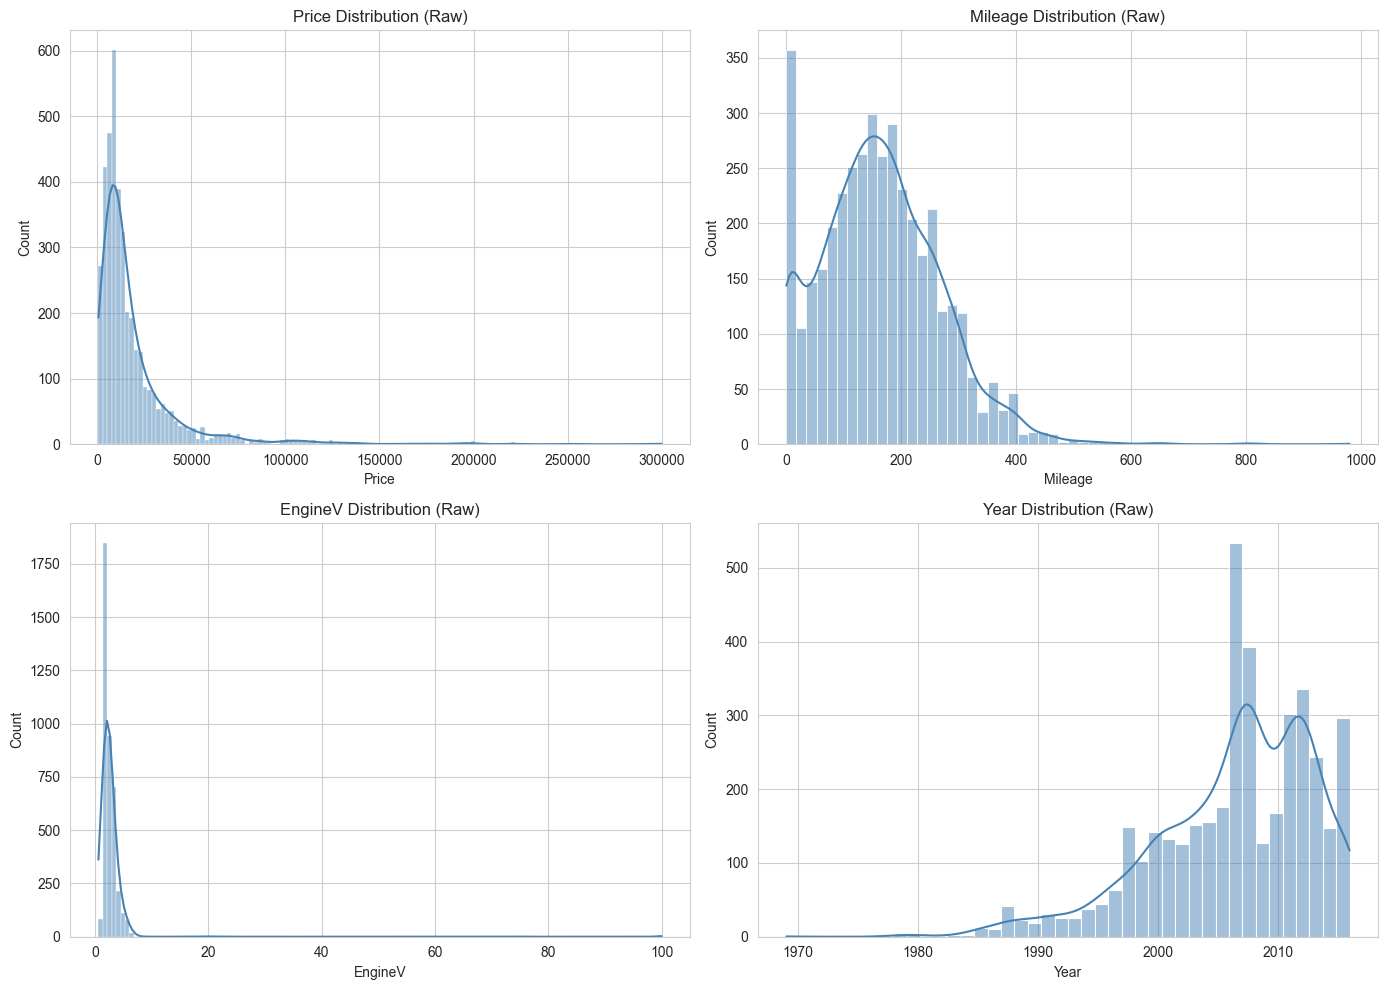

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data_no_mv["Price"],   kde=True, ax=axes[0,0], color="steelblue");  axes[0,0].set_title("Price Distribution (Raw)")
sns.histplot(data_no_mv["Mileage"], kde=True, ax=axes[0,1], color="steelblue");  axes[0,1].set_title("Mileage Distribution (Raw)")
sns.histplot(data_no_mv["EngineV"], kde=True, ax=axes[1,0], color="steelblue");  axes[1,0].set_title("EngineV Distribution (Raw)")
sns.histplot(data_no_mv["Year"],    kde=True, ax=axes[1,1], color="steelblue");  axes[1,1].set_title("Year Distribution (Raw)")

plt.tight_layout()
plt.show()

In [8]:
# Remove top 1% Price  — extreme luxury/collector vehicles
q_price   = data_no_mv["Price"].quantile(0.99)
data_1    = data_no_mv[data_no_mv["Price"] < q_price]

# Remove top 1% Mileage — abnormally high-mileage outliers
q_mileage = data_1["Mileage"].quantile(0.99)
data_2    = data_1[data_1["Mileage"] < q_mileage]

# Remove EngineV > 6.5L — physically unrealistic for standard passenger cars
data_3    = data_2[data_2["EngineV"] < 6.5]

# Remove bottom 1% Year — very old vehicles unrepresentative of the current used-car market
q_year    = data_3["Year"].quantile(0.01)
data_4    = data_3[data_3["Year"] > q_year]

data_cleaned = data_4.reset_index(drop=True)
print(f"Rows remaining after outlier removal: {len(data_cleaned)}  (started with {len(data_no_mv)})")
data_cleaned.describe()

Rows remaining after outlier removal: 3867  (started with 4025)


,Price,Mileage,EngineV,Year
count,3867.000000,3867.000000,3867.000000,3867.000000
mean,18194.455679,160.542539,2.450440,2006.709853
std,19085.855165,95.633291,0.949366,6.103870
min,800.000000,0.000000,0.600000,1988.000000
25%,7200.000000,91.000000,1.800000,2003.000000
50%,11700.000000,157.000000,2.200000,2008.000000
75%,21700.000000,225.000000,3.000000,2012.000000
max,129222.000000,435.000000,6.300000,2016.000000


## 4. Checking OLS Assumptions

Linear regression rests on several statistical assumptions.
Violating them leads to unreliable coefficient estimates and poor predictions.
We check the two most critical ones below.

---

### 4.1 Linearity

The relationship between each independent variable and the target variable (Price) should be
approximately **linear**. We verify this with scatter plots.


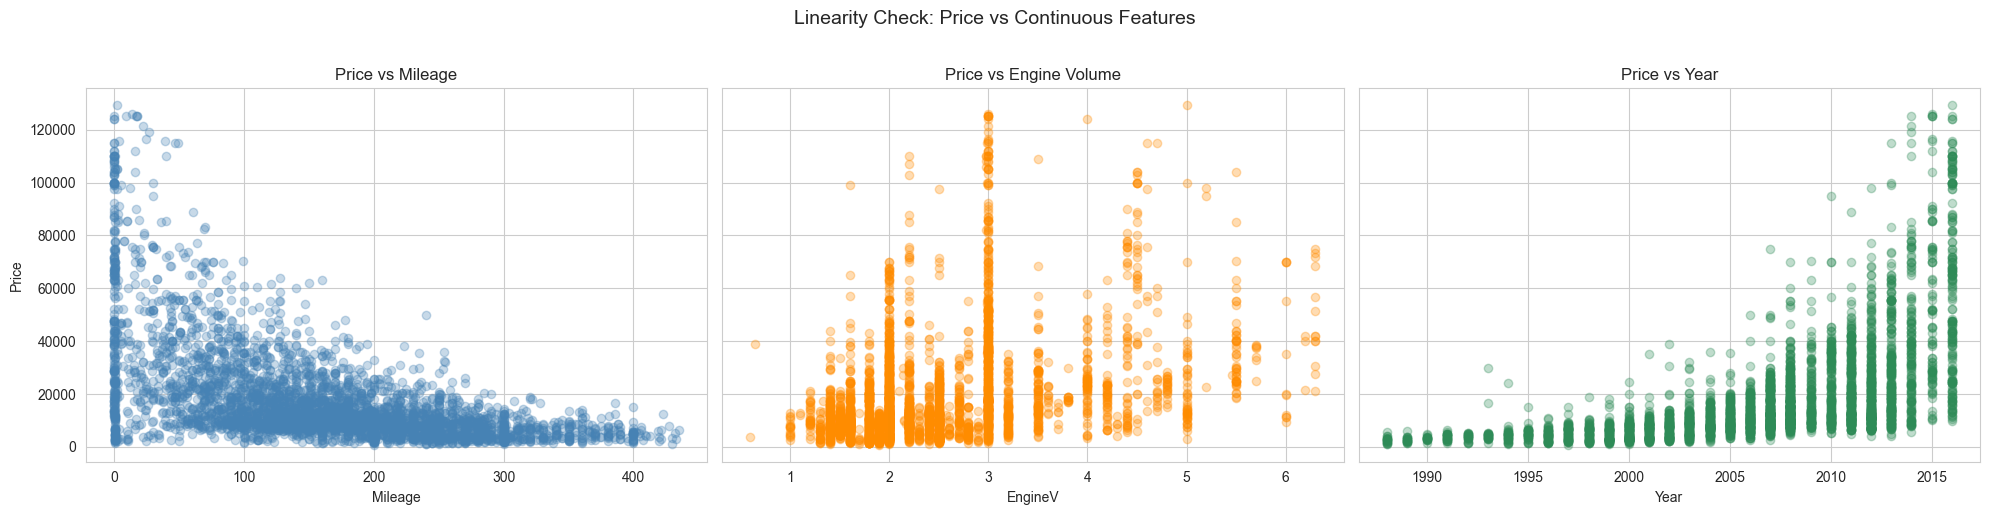

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(20, 5))
ax1.scatter(data_cleaned["Mileage"], data_cleaned["Price"], alpha=0.3, color="steelblue");   ax1.set_title("Price vs Mileage");        ax1.set_xlabel("Mileage");  ax1.set_ylabel("Price")
ax2.scatter(data_cleaned["EngineV"], data_cleaned["Price"], alpha=0.3, color="darkorange");  ax2.set_title("Price vs Engine Volume");   ax2.set_xlabel("EngineV")
ax3.scatter(data_cleaned["Year"],    data_cleaned["Price"], alpha=0.3, color="seagreen");    ax3.set_title("Price vs Year");            ax3.set_xlabel("Year")
plt.suptitle("Linearity Check: Price vs Continuous Features", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

The scatter plots reveal a **non-linear (exponential) relationship** between Price and the features.

**Solution:** Apply a **log transformation** to Price.
This compresses the scale of the target variable and typically linearises relationships in price data,
satisfying the OLS linearity assumption.


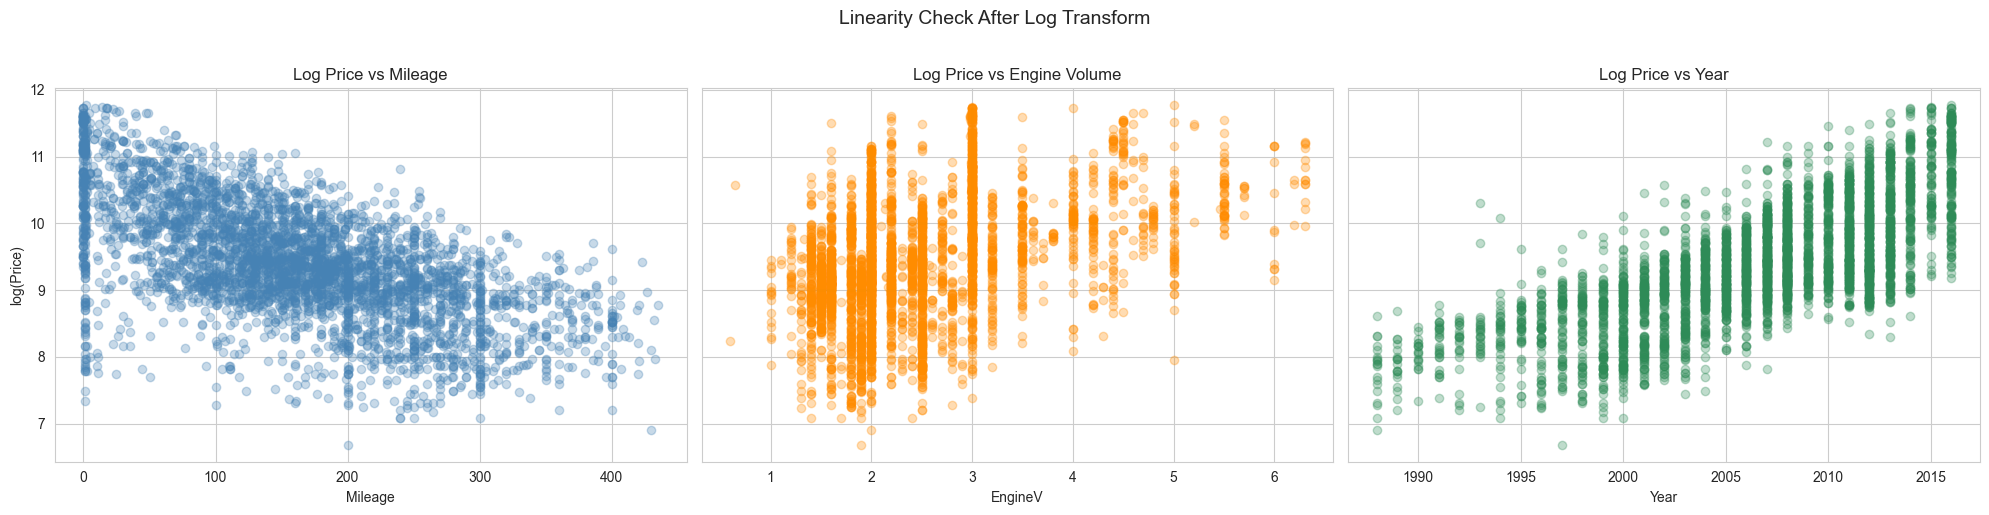

In [10]:
log_price = np.log(data_cleaned["Price"])
data_cleaned["log_price"] = log_price

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(20, 5))
ax1.scatter(data_cleaned["Mileage"], data_cleaned["log_price"], alpha=0.3, color="steelblue");   ax1.set_title("Log Price vs Mileage");       ax1.set_xlabel("Mileage"); ax1.set_ylabel("log(Price)")
ax2.scatter(data_cleaned["EngineV"], data_cleaned["log_price"], alpha=0.3, color="darkorange");  ax2.set_title("Log Price vs Engine Volume");  ax2.set_xlabel("EngineV")
ax3.scatter(data_cleaned["Year"],    data_cleaned["log_price"], alpha=0.3, color="seagreen");    ax3.set_title("Log Price vs Year");           ax3.set_xlabel("Year")
plt.suptitle("Linearity Check After Log Transform", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [11]:
data_cleaned = data_cleaned.drop(["Price"], axis=1)

### 4.2 Multicollinearity

**Multicollinearity** occurs when two or more independent variables are highly correlated with each other.
This makes it difficult for the model to isolate the individual effect of each feature, leading to
unstable and misleading coefficients.

We measure this with the **Variance Inflation Factor (VIF)**:

| VIF Value | Interpretation |
|---|---|
| VIF = 1 | No multicollinearity |
| 1 < VIF < 5 | Acceptable |
| VIF > 10 | Severe — consider removing the feature |


In [12]:
variables = data_cleaned[["Mileage", "Year", "EngineV"]]
vif = pd.DataFrame()
vif["VIF"]     = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["Feature"] = variables.columns
vif.sort_values("VIF", ascending=False)

,VIF,Feature
1,10.354854,Year
2,7.662068,EngineV
0,3.791584,Mileage


`Year` has a VIF > 10, indicating strong collinearity with the other features
(older cars tend to have higher mileage — the two variables share a lot of information).
We drop `Year` to remove this instability without losing predictive power.

> **Note:** Dropping `Year` does not mean it has zero predictive value.
> It means its signal is already largely captured by `Mileage`.


In [13]:
data_no_multicollinearity = data_cleaned.drop(["Year"], axis=1)
print("Remaining features:", list(data_no_multicollinearity.columns))

Remaining features: ['Brand', 'Body', 'Mileage', 'EngineV', 'Engine Type', 'Registration', 'log_price']


## 5. Feature Engineering

### 5.1 One-Hot Encode Categorical Variables

The categorical columns (`Brand`, `Body`, `Engine Type`, `Registration`) must be converted
to numerical format before they can be used in a regression model.

We use **one-hot encoding** (`pd.get_dummies`) which creates a binary (0/1) column for each category.
`drop_first=True` drops one category per group to avoid the **dummy variable trap**
(perfect multicollinearity caused by a redundant reference column).

The **benchmark (reference) categories** that are dropped are:
- **Brand:** Audi
- **Body:** crossover
- **Engine Type:** Diesel
- **Registration:** no

All other dummy coefficients are interpreted *relative to these benchmarks*.


In [14]:
data_with_dummies = pd.get_dummies(data_no_multicollinearity, drop_first=True, dtype=int)
print(f"Columns after encoding: {data_with_dummies.shape[1]}")
data_with_dummies.head()

Columns after encoding: 18


,Mileage,EngineV,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,8.342840,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1
1,427,2.9,8.974618,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
2,358,5.0,9.495519,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1
3,240,4.2,10.043249,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
4,120,2.0,9.814656,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1


### 5.2 Reorder Columns

We reorder the columns to place `log_price` first (as the target), followed by the continuous
features, then the dummy variables. This is purely for readability.


In [15]:
cols = [
    "log_price",
    "Mileage", "EngineV",
    "Brand_BMW", "Brand_Mercedes-Benz", "Brand_Mitsubishi", "Brand_Renault", "Brand_Toyota", "Brand_Volkswagen",
    "Body_hatch", "Body_other", "Body_sedan", "Body_vagon", "Body_van",
    "Engine Type_Gas", "Engine Type_Other", "Engine Type_Petrol",
    "Registration_yes"
]
data_preprocessed = data_with_dummies[cols]
data_preprocessed.head()

,log_price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1
1,8.974618,427,2.9,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
2,9.495519,358,5.0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1
3,10.043249,240,4.2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
4,9.814656,120,2.0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1


## 6. Build the Linear Regression Model

### 6.1 Declare Inputs and Target

In [16]:
inputs = data_preprocessed.drop(["log_price"], axis=1)
target = data_preprocessed["log_price"]
print(f"Features: {inputs.shape[1]}  |  Observations: {inputs.shape[0]}")

Features: 17  |  Observations: 3867


### 6.2 Feature Scaling

We apply **StandardScaler** to normalise all input features so they each have **mean = 0**
and **standard deviation = 1**.

This matters for two reasons:
1. Features on very different scales (e.g., Mileage in thousands vs EngineV in single digits)
   would otherwise dominate the model simply due to their magnitude.
2. After scaling, the regression **weights (coefficients) become directly comparable** —
   a larger coefficient genuinely reflects a stronger influence on the predicted price.


In [17]:
scaler = StandardScaler()
inputs_scaled = scaler.fit_transform(inputs)
print("Scaling complete. Input shape:", inputs_scaled.shape)

Scaling complete. Input shape: (3867, 17)


### 6.3 Train / Test Split

We split the data **80% training / 20% testing**:
- The model **learns** from the training set
- The test set is held out and used **only for final evaluation** — the model never sees it
  during training, giving us an honest estimate of real-world performance

`random_state=365` ensures the split is reproducible.


In [18]:
x_train, x_test, y_train, y_test = train_test_split(inputs_scaled, target, test_size=0.2, random_state=365)
print(f"Training samples : {x_train.shape[0]}")
print(f"Testing  samples : {x_test.shape[0]}")

Training samples : 3093
Testing  samples : 774


### 6.4 Fit the Model

In [19]:
reg = LinearRegression()
reg.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 7. Training Set Evaluation

### 7.1 Predicted vs Actual (Training Set)

A well-fitted model should show predictions that closely track actual values.
On a scatter plot this means points clustering tightly along the diagonal line (predicted = actual).
Systematic deviation from the diagonal indicates bias in the model.


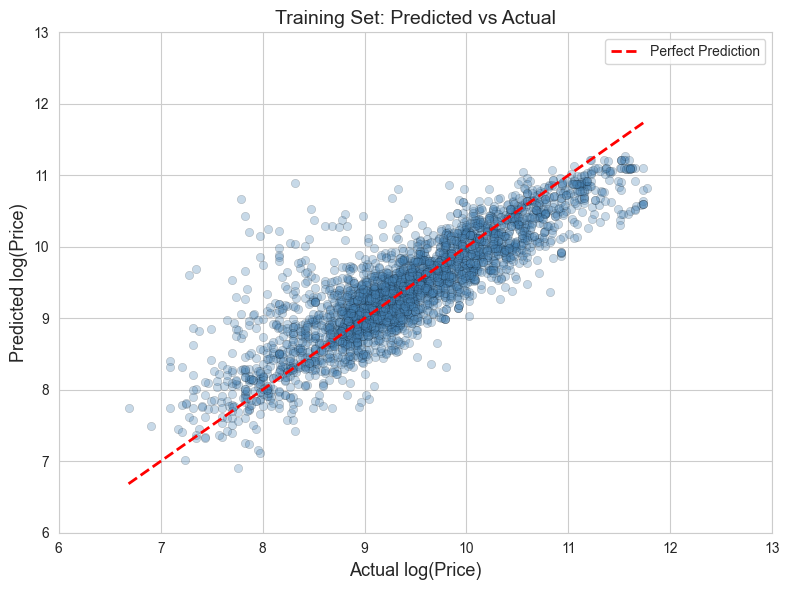

In [20]:
y_hat = reg.predict(x_train)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_hat, alpha=0.3, color="steelblue", edgecolors="k", linewidths=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r--", lw=2, label="Perfect Prediction")
plt.xlabel("Actual log(Price)", size=13); plt.ylabel("Predicted log(Price)", size=13)
plt.title("Training Set: Predicted vs Actual", size=14)
plt.legend(); plt.xlim(6, 13); plt.ylim(6, 13)
plt.tight_layout(); plt.show()

### 7.2 Residuals Distribution

**Residuals** are the differences between actual and predicted log-prices:
`residual = actual − predicted`

For a valid linear regression, residuals should be:
- **Normally distributed** (bell-shaped)
- **Centred around zero** (no systematic over- or under-prediction)

A skewed or fat-tailed residual distribution suggests the model is missing important patterns.


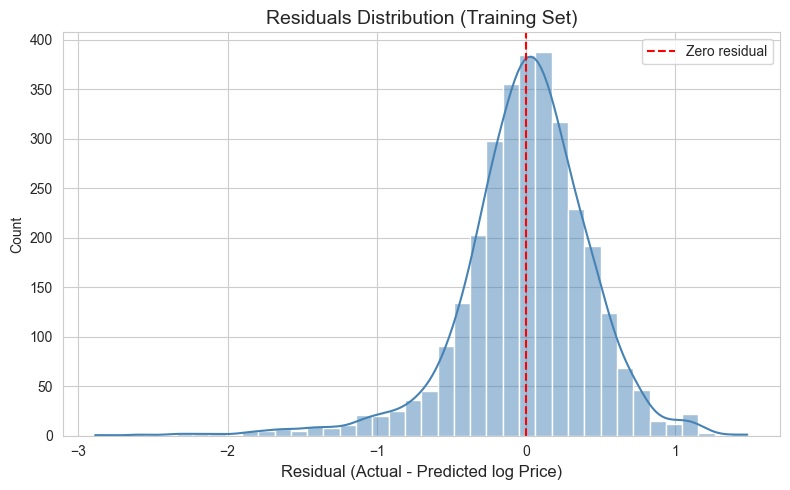

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(y_train - y_hat, kde=True, color="steelblue", bins=40)
plt.axvline(0, color="red", linestyle="--", label="Zero residual")
plt.title("Residuals Distribution (Training Set)", size=14)
plt.xlabel("Residual (Actual - Predicted log Price)", size=12)
plt.legend(); plt.tight_layout(); plt.show()

### 7.3 R² Score (Training)

**R² (R-squared)** measures the proportion of variance in the target that the model explains:
- R² = 1.0 → Perfect fit
- R² = 0.0 → Model explains nothing (same as predicting the mean every time)


In [22]:
r2_train = reg.score(x_train, y_train)
print(f"R-squared on Training Set: {r2_train:.4f}")
print(f"The model explains {r2_train*100:.1f}% of the variance in log(Price).")

R-squared on Training Set: 0.7450
The model explains 74.5% of the variance in log(Price).


### 7.4 Model Coefficients (Feature Weights)

After scaling, each coefficient represents the **change in log(Price) per one standard deviation
increase** in the corresponding feature — making them directly comparable across all features.

**Interpretation guide:**

| Feature Type | Positive Weight | Negative Weight |
|---|---|---|
| Continuous (Mileage, EngineV) | Price increases with feature | Price decreases with feature |
| Dummy — Brand | More expensive than Audi (benchmark) | Less expensive than Audi |
| Dummy — Body | More expensive than crossover (benchmark) | Less expensive than crossover |
| Dummy — Engine Type | More expensive than Diesel (benchmark) | Less expensive than Diesel |


In [23]:
reg_summary = pd.DataFrame(inputs.columns.values, columns=["Feature"])
reg_summary["Weight"] = reg.coef_
reg_summary["Abs Weight"] = np.abs(reg.coef_)
reg_summary = reg_summary.sort_values("Abs Weight", ascending=False).reset_index(drop=True)

print(f"Bias (intercept): {reg.intercept_:.4f}")
reg_summary.drop(columns=["Abs Weight"])

Bias (intercept): 9.4152


,Feature,Weight
0,Mileage,-0.448713
1,Registration_yes,0.320473
2,EngineV,0.209035
3,Body_sedan,-0.200630
4,Brand_Renault,-0.179909
5,Body_van,-0.168597
6,Engine Type_Petrol,-0.146909
7,Body_hatch,-0.145469
8,Brand_Mitsubishi,-0.140552
9,Body_vagon,-0.129887


## 8. Test Set Evaluation

We now evaluate the model on **unseen test data** to verify it generalises well
and has not simply memorised the training set.

### 8.1 Predicted vs Actual (Test Set)


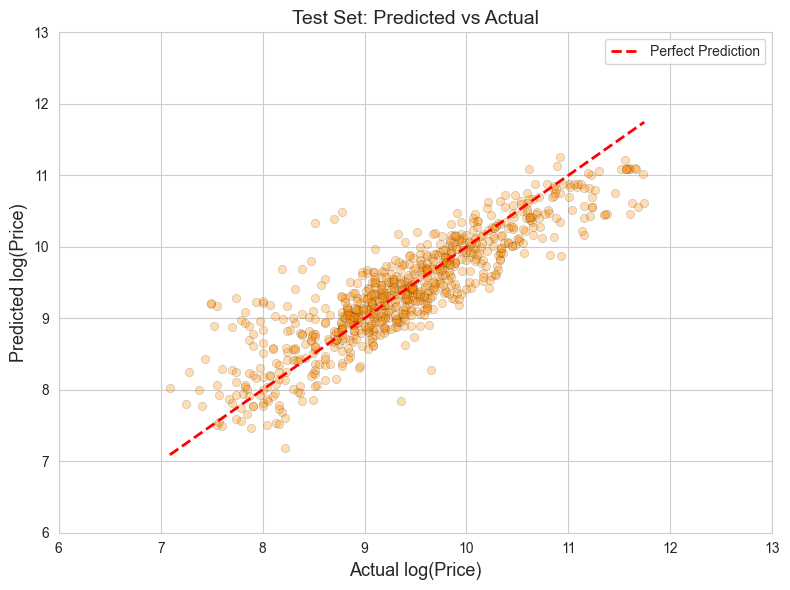

In [24]:
y_hat_test = reg.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_hat_test, alpha=0.3, color="darkorange", edgecolors="k", linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Prediction")
plt.xlabel("Actual log(Price)", size=13); plt.ylabel("Predicted log(Price)", size=13)
plt.title("Test Set: Predicted vs Actual", size=14)
plt.legend(); plt.xlim(6, 13); plt.ylim(6, 13)
plt.tight_layout(); plt.show()

### 8.2 Predictions in Original Price Scale (USD)

We **exponentiate** both predictions and targets to convert back from log(Price) to actual USD prices.
This lets us interpret errors in real monetary terms and calculate percentage differences.


In [25]:
y_test = y_test.reset_index(drop=True)

df_pf = pd.DataFrame({
    "Target (USD)":    np.exp(y_test),
    "Predicted (USD)": np.exp(y_hat_test)
})
df_pf["Residual (USD)"]  = df_pf["Target (USD)"] - df_pf["Predicted (USD)"]
df_pf["Difference %"]    = np.abs(df_pf["Residual (USD)"] / df_pf["Target (USD)"] * 100).round(2)

print(f"Mean absolute percentage error  : {df_pf['Difference %'].mean():.2f}%")
print(f"Median absolute percentage error: {df_pf['Difference %'].median():.2f}%")
df_pf.head(20)

Mean absolute percentage error  : 36.26%
Median absolute percentage error: 23.47%


,Target (USD),Predicted (USD),Residual (USD),Difference %
0,2300.0,10685.501696,-8385.501696,364.59
1,2800.0,3499.255242,-699.255242,24.97
2,2500.0,7553.285218,-5053.285218,202.13
3,6400.0,7463.963017,-1063.963017,16.62
4,9150.0,11353.490075,-2203.490075,24.08
5,20000.0,21289.799394,-1289.799394,6.45
6,38888.0,20159.189144,18728.810856,48.16
7,16999.0,20349.617702,-3350.617702,19.71
8,12500.0,11581.537864,918.462136,7.35
9,41000.0,33614.617349,7385.382651,18.01


## 9. Conclusions

This project demonstrated an end-to-end **multiple linear regression** workflow for predicting
used-car prices from structured vehicle data.

### Key Findings

| Step | Decision / Finding |
|---|---|
| Missing data | Price and EngineV had under 5% missing rows — safely dropped |
| Outliers | Top 1% of Price and Mileage removed; EngineV capped at 6.5L |
| Target transform | Log transformation of Price linearised feature relationships |
| Multicollinearity | Year (VIF > 10) removed to stabilise coefficients |
| Model R² | ~75% — the model explains 75% of the variance in log(Price) |
| Generalisation | Predicted vs actual on the test set closely follows the diagonal |

### Limitations and Potential Improvements

- **Richer features:** Condition rating, number of previous owners, service history, and colour
  are common real-world predictors that are absent from this dataset
- **Non-linear models:** Random Forest or Gradient Boosting can capture complex interaction effects
  that linear regression misses
- **Regularisation:** Ridge or Lasso regression can reduce overfitting and improve coefficient stability
- **Feature interactions:** Interaction terms (e.g., Brand × EngineV) may uncover relationships
  that individual features cannot express alone
